# ANALYSE EXPLORATOIRE DE DONNÉES  

Ce notebook vise à produire une analyse exploratoire de données, de raconter l'histoire des données de nexacommerce, ce qui constitueras notre rapport final. L'objectif seras donc :

1.  Nettoyer et normalise les données

2.  Des visualisation pour raconter l'histoire de la données

3.  Identifiez les insights les plus actionnables 

**Objectifs** : *Racontez les données de nexacommerce*

## Chargement des données 

Ici nous importons les données, les biblothèques que nous allons utiliser tout au long de notre notebook 

In [ ]:
from nexacommerce.config import *
from nexacommerce.data_loader import CSVLoader 
from nexacommerce.inspection import inspect_dataset
from datetime import datetime
from scipy.stats import ttest_ind
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

order_loader =CSVLoader(ORDERS_FILE)
order_items_loader = CSVLoader(ORDER_ITEMS_FILE)
courier_loader = CSVLoader(COURIERS_FILE)
customer_loader = CSVLoader(CUSTOMERS_FILE)

orders = order_loader.load()
customers = customer_loader.load()
couriers = courier_loader.load()
orders_item = order_items_loader.load() 


## Pipeline de nettoyage 

Ici nous aurons pour but de comprendre les données et enfin de nettoyer ce qui ne vas pas dans la donnée:
 
- normalisation des statuts,

- normalisation des villes,

- normalise les dates,

- correction analytique des montants, 

- déduplication des clients.

In [178]:
# Inspection des valeurs sur orders 
inspection_orders = inspect_dataset(orders)
# Inspection des valeurs sur customers
inspection_customer = inspect_dataset(customers) 

# Doublons des id de orders et téléphone dand customer 
print(f'Doublons complets : {orders.duplicated().sum()}')
print(f'order_id unique: {orders["order_id"].nunique()} / {len(orders)}')
print(f'Doublons numéro téléphone: {customers[customers["phone"].notna()].duplicated(subset="phone", keep=False).sum()}')
print(f'Téléphone unique: {customers["phone"].nunique()} / {len(customers)} ')

# Verification des variantes et des colonnes
for col in ['status', 'city', 'product_category']:
    print(f'\n{col} ({orders[col].nunique()} valeurs uniques):')
    print(orders[col].value_counts(dropna=False).head(10))
    
# # Distinction des dates   
date_cols = [c for c in orders.columns if "date" in c.lower()]
if not date_cols:
    print("\nAucune colonne contenant 'date'")
else:
    for c in date_cols:
        print(f"\Collone: {c} — Valeur distinctes :", orders[c].nunique(dropna=False))
        print(orders[c].astype(str).str.strip().value_counts(dropna=False))        
        
 
# Nombre doublons de téléphone dans la table Order
doublons = customers[customers['phone'].notna()].duplicated(subset='phone', keep=False)
print(f'\nClients avec doublons téléphone : {doublons.sum()}')       

print(inspection_customer)
print(inspection_orders)

Doublons complets : 0
order_id unique: 12500 / 12500
Doublons numéro téléphone: 144
Téléphone unique: 2308 / 2380 

status (17 valeurs uniques):
status
livrÃ©       7499
en_retard    2429
annulÃ©       978
en_cours      286
LivrÃ©        261
livre         144
LIVRE         135
En_retard     131
en retard     119
AnnulÃ©        73
Name: count, dtype: int64

city (14 valeurs uniques):
city
Douala       1311
douala       1309
Douala       1293
douala       1277
DOUALA       1232
YaoundÃ©      845
YaoundÃ©      839
yaounde       833
Yaounde       812
YAOUNDE       806
Name: count, dtype: int64

product_category (38 valeurs uniques):
product_category
NaN               2078
Restauration       472
Resaturation       449
Restaurant         437
restauration       427
BOISSONS           320
produits_frais     317
Produits Frais     310
EPICERIE           308
boissons           307
Name: count, dtype: int64
\Collone: order_date — Valeur distinctes : 11194
order_date
14-03-2025             9
11-03

## Normalisation ds données 

La cellule précedente nous montre des variations de ligne et de colonne sur la table ordes et customers :

- 17 variantes de statut plus ou moins identique avec aucune ligne vides,

- 14 Valeur de ville plus ou moins identifque et aucune ligne vides,

- Normalisation des dates,

- 38 valeur de product category qui sont identiques mais avons des noms plus ou moins identiques et des valeurs dont je vais remplacer en joinant order_items,  

- Des valeurs null à loyalty_score pour la table customer que je vais remettre à 0 plus cohérent et supérieur à 100 je ramene à 100,     

- Des montants négatifs que je vais mettre en valeur absolute, 

- Des valeurs nulle à delivery_time_min de la table orders que je vais inputer par la médianne.

- Les montants sont en float ramener dans un type int.

### Normalisation des données

#### Normalisation des status

In [179]:
def status_normalise(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    if value in {"livrÃ©", "LivrÃ©", "LIVRE", "livre", "livré", "livrã©"}:
        return "livré"
    if value in {"en_retard", "en retard", "retard", "En_retard", "EN_RETARD"}:
        return "en_retard"
    if value in {"annule", "ANNULE", "AnnulÃ©", "annulÃ©","annulã©"}:
        return "annulé"
    if value in {"en_cours", "en cours","En_cours"}:
        return "en_cours"
    return value.strip().lower()

#### Normalisation des villes

In [180]:
def city_normalise(value):
    if pd.isna(value):
        return np.nan
    if value in {"Yaoundã©","Yaoundã©","YaoundÃ©","Yaoundã©"}:
        return "Yaounde"
    value = str(value).strip().lower()
    return value.capitalize()    

#### Normalisation des dates


In [ ]:
# Type de formats constater
DATE_FORMATS = [
    "%Y-%m-%d %H:%M:%S",
    "%Y/%m/%d %H:%M",
    "%d/%m/%Y %H:%M",
    "%d-%m-%Y %H:%M",    
    "%Y-%m-%d",
    "%Y/%m/%d",
    "%d/%m/%Y",
    "%d-%m-%Y",
    "%d %B %Y",
    "%m/%d/%Y",
    "%m-%d-%Y",    
    "%m/%d/%Y %H:%M",
]  

# Fonction normalisation
def date_normalise(value):
    if pd.isna(value):
        return pd.NaT 
    
    value = str(value).strip()
    for fmt in DATE_FORMATS:
        try:
            return pd.to_datetime(datetime.strptime(value, fmt))
        except ValueError:
            continue

    return pd.NaT 

#### Normalisation des numeros de teléphone de la table customers

In [182]:
def normalise_phone(phone):
    if pd.isna(phone): 
        return None
    # Supprimer tout ce qui n'est pas un chiffre
    digits = re.sub(r'\D', '', str(phone))
    # Retirer le préfixe international 237
    if digits.startswith('237') and len(digits) == 12:
        digits = digits[3:]
    # Doit faire 9 chiffres et commencer par 6 ou 2
    if len(digits) == 9 and digits[0] in ('6', '2'):
        return digits
    return None # Format non reconnu

#### Imputation à la médiane de delivery_time_min

Ici nous ramenons les valeurs qui sont nul à la mediane

In [183]:
médiane_durée = orders['delivery_time_min'].median()
print(f'Médiane durée : {médiane_durée:.1f} min')
orders['delivery_time_min'] = orders['delivery_time_min'].fillna(médiane_durée)

Médiane durée : 45.7 min


#### Ramener les montants du type float au type float

In [184]:
orders['total_amount_xaf'] = orders['total_amount_xaf'].abs()

customers['registration_date'] = pd.to_datetime(customers['registration_date'], errors="coerce")

#### Remplir les catégories pour la table orders

In [185]:
cat_par_ordre = (orders_item
    .groupby('order_id')['product_category']
    .first() # prendre la 1ère catégorie si plusieurs produits
    .reset_index()
    .rename(columns={'product_category': 'cat_from_items'})
)
orders = orders.merge(cat_par_ordre, on='order_id', how='left')
# Remplir product_category par la valeur récupérée de order_item

mask_cat_null = orders['product_category'].isnull()
orders.loc[mask_cat_null, 'product_category'] = orders.loc[mask_cat_null,
'cat_from_items']
orders.drop(columns=['cat_from_items'], inplace=True)
récupérés = mask_cat_null.sum() - orders['product_category'].isnull().sum()
print(f'Catégories récupérées depuis order_items : {récupérés}')
print(f'Catégories encore manquantes: {orders["product_category"].isnull().sum()}')

Catégories récupérées depuis order_items : 2078
Catégories encore manquantes: 0


#### Loyalty_score ramener à 100 et mettre à 0 

In [186]:
outliers = (customers['loyalty_score'] > 100).sum()
print(f'\nScores > 100 : {outliers}')

customers['loyalty_score'] = customers['loyalty_score'].clip(lower=0, upper=100)


Scores > 100 : 107


#### Déduplication des clients



In [292]:
customers_dup = (
    customers
    .sort_values(["phone", "registration_date"])
    .drop_duplicates(subset=["phone"], keep="first")
    .copy()
)

print("Customers before dedup:", customers.shape[0])
print("Customers after dedup :", customers_dup.shape[0])
print(f"FInal { customers.shape[0] - customers_dup.shape[0]}")


Customers before dedup: 2380
Customers after dedup : 1918
FInal 462


### Application des normalisation sur les différentes tables

In [ ]:
# Mettre à 0
customers['loyalty_score'] = customers['loyalty_score'].fillna(0)

# Normalisation des phone
customers['phone'] = customers['phone'].map(normalise_phone)

# Normalisation des villes
orders['city'] = orders['city'].map(city_normalise)
customers['city'] = customers['city'].map(city_normalise)

# Normalisation des status
orders['status'] = orders['status'].map(status_normalise)

#Normalise les dates
orders['order_date'] = orders['order_date'].map(date_normalise)

### Verification des données correcte

In [ ]:
# Vérification des villes des status des categories
for col in ['status', 'city', 'product_category']:
    print(f'\n{col} ({orders[col].nunique()} valeurs uniques):')
    print(orders[col].value_counts(dropna=False).head(10))
    
# Doublons par téléphone
doublons = customers[customers['phone'].notna()].duplicated(subset='phone', keep=False)
print(f'\nClients avec doublons téléphone : {doublons.sum()}')  
print(customers['phone'].head())

# Garder un seul enregistrement par téléphone (le plus récent)
customers_dedup = (customers[customers['phone'].notna()]
.sort_values('registration_date', ascending=False)
.drop_duplicates(subset='phone', keep='first')
)  

# Valeur null delivery_time_null
print(f"Valeur nulle pour les montants et le temps livraison : {orders[['total_amount_xaf','delivery_time_min']].isna().sum()}")


# Valeur de total_amount_xaf
print(orders.loc[0:4, 'total_amount_xaf'])

print(inspection_orders)
print(inspection_customer)


status (4 valeurs uniques):
status
livré        8103
en_retard    2802
annulé       1170
en_cours      425
Name: count, dtype: int64

city (3 valeurs uniques):
city
Douala       6422
Yaounde      4135
Bafoussam    1943
Name: count, dtype: int64

product_category (38 valeurs uniques):
product_category
Restauration      727
Ãpicerie         695
Produits frais    553
Boissons          540
Pharmacie         460
Resaturation      449
Restaurant        437
restauration      427
Papeterie         417
Ãlectronique     391
Name: count, dtype: int64

Clients avec doublons téléphone : 464
0    653091709
1    638270233
2          NaN
3    688339168
4    660015814
Name: phone, dtype: str
Delivery_time_min restants à null : 0
0    15444.0
1    16188.0
2    11497.0
3    20301.0
4    15639.0
Name: total_amount_xaf, dtype: float64


## Visualisation 

Ici nous devrons mettre à disposition des visualisation qui porteront sur : 

- l'evolution temporelle du volume de commandes

- La répartition géographique des performances 

- Le profil de clients actifs contre ceux inactifs

- L'analyse de crénaux horaires

### Montrons l'evolution du volume de commandes 

        month  nbre_orders
0  2022-01-01           46
1  2022-02-01           66
2  2022-03-01           92
3  2022-04-01          105
4  2022-05-01          141
5  2022-06-01          129
6  2022-07-01          161
7  2022-08-01          180
8  2022-09-01          185
9  2022-10-01          222
10 2022-11-01          198
11 2022-12-01          210
12 2023-01-01          212
13 2023-02-01          213
14 2023-03-01          263
15 2023-04-01          242
16 2023-05-01          298
17 2023-06-01          274
18 2023-07-01          285
19 2023-08-01          302
20 2023-09-01          313
21 2023-10-01          338
22 2023-11-01          337
23 2023-12-01          352
24 2024-01-01          366
25 2024-02-01          363
26 2024-03-01          411
27 2024-04-01          374
28 2024-05-01          450
29 2024-06-01          434
30 2024-07-01          446
31 2024-08-01          456
32 2024-09-01          492
33 2024-10-01          529
34 2024-11-01          490
35 2024-12-01          614
3

/home/unix/.cache/pypoetry/virtualenvs/projet-1-data-ia-enginner-IqQgIR_N-py3.11/lib/python3.11/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


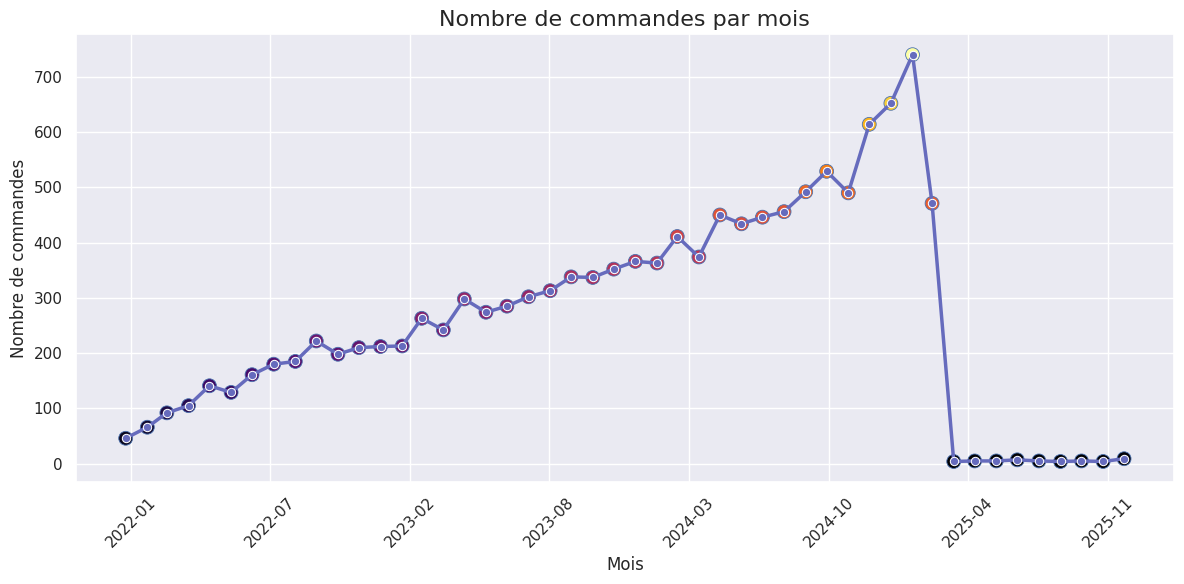

In [ ]:
# compter par mois (timestamp = début du mois) et recupérer uniquement les mois dans order_date 
monthly = (orders.groupby(orders['order_date'].dt.to_period('M'))['order_id']
           .count()
           .sort_index()
           .to_timestamp()
           .reset_index()
           )

# DataFrame résultat 
# Series en dataFrame
monthly.columns = ['month', 'nbre_orders']
monthly['month'] = pd.to_datetime(monthly['month'])  # garantir datetime

# afficher le tableau
print(monthly)

# graphique esthétique avec seaborn
sns.set_theme(style="darkgrid")
plt.figure(figsize=(12,6))
palette = sns.color_palette("mako", n_colors=1)[0]

sns.lineplot(data=monthly, x='month', y='nbre_orders', marker='o', color="#666BBD", linewidth=2.5)
sns.scatterplot(data=monthly, x='month', y='nbre_orders',
                hue='nbre_orders', palette="inferno", legend=False, s=100, edgecolor='b', linewidth=0.6,  cmap="inferno", )

plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
plt.title("Nombre de commandes par mois", fontsize=16)
plt.xlabel("Mois")
plt.ylabel("Nombre de commandes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Commentaire

Cette visualisation permet de voir la dynamique de l'activité dans le temps. Elle aide à repérer les phases d'accélération, les creux d'activité et l'éventuelle saisonnalité du volume de commande. Nous constatons que nous avons eu une reduction enorme du nombre de commande au niveau du mois de février en 2025, les commandes on drastiquement diminuer. 

### Répartition géographique des performances

        month  total_amount
0  2022-01-01     1184674.0
1  2022-02-01     2157509.0
2  2022-03-01     3051625.0
3  2022-04-01     3008450.0
4  2022-05-01     6395772.0
5  2022-06-01     6147894.0
6  2022-07-01     5900699.0
7  2022-08-01     5094392.0
8  2022-09-01     4971000.0
9  2022-10-01     6148643.0
10 2022-11-01     6662740.0
11 2022-12-01     5820801.0
12 2023-01-01     8071259.0
13 2023-02-01     6637188.0
14 2023-03-01     7550349.0
15 2023-04-01     7548647.0
16 2023-05-01     9277177.0
17 2023-06-01     7788413.0
18 2023-07-01     9141870.0
19 2023-08-01     8517593.0
20 2023-09-01     9301703.0
21 2023-10-01    10773686.0
22 2023-11-01    10155607.0
23 2023-12-01    10498425.0
24 2024-01-01    12072910.0
25 2024-02-01    14063569.0
26 2024-03-01    13814383.0
27 2024-04-01    11845877.0
28 2024-05-01    15738758.0
29 2024-06-01    15817695.0
30 2024-07-01    13184208.0
31 2024-08-01    14152159.0
32 2024-09-01    15636075.0
33 2024-10-01    14789623.0
34 2024-11-01    138

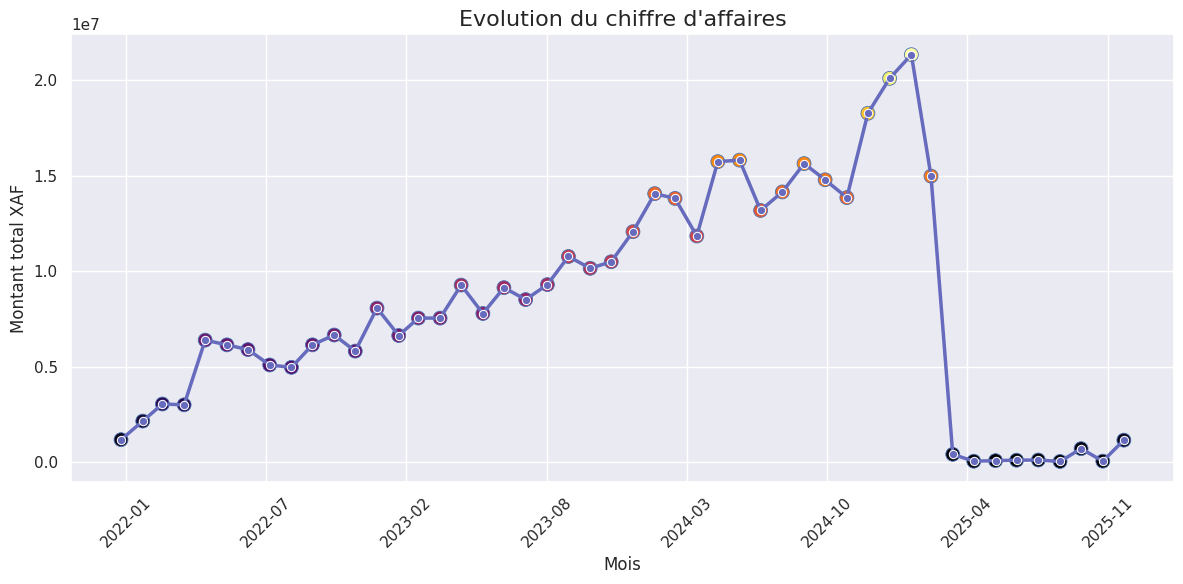

In [291]:
CA_monthly = (
    orders.groupby(orders['order_date'].dt.to_period('M'))['total_amount_xaf']
    .sum()
    .sort_index()
    .to_timestamp()
    .reset_index()
)

# Series en dataFrame
CA_monthly.columns = ['month', 'total_amount']
CA_monthly['month'] = pd.to_datetime(CA_monthly['month'])  # garantir datetime

# afficher le tableau
print(CA_monthly)

sns.set_theme(style="darkgrid")
plt.figure(figsize=(12,6))
palette = sns.color_palette("mako", n_colors=1)[0]

sns.lineplot(data=CA_monthly, x='month', y='total_amount', marker='o', color="#666BBD", linewidth=2.5)
sns.scatterplot(data=CA_monthly, x='month', y='total_amount',
                hue='total_amount', palette="inferno", legend=False, s=100, edgecolor='b', linewidth=0.6)

plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))
plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
plt.title("Evolution du chiffre d'affaires", fontsize=16)
plt.xlabel("Mois")
plt.ylabel("Montant total XAF")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Interprétation

Le chiffe d'affaire complète absolument le volume de commande par mois. Une hausse des commandes ne traduit pas toujours une hausse proportionnelle au revenu. 

### Profils clients actifs vs inactifs

/tmp/ipykernel_5240/2541258605.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=counts, y='profile', x='count', palette=palette, order=['Actif','Inactif'])


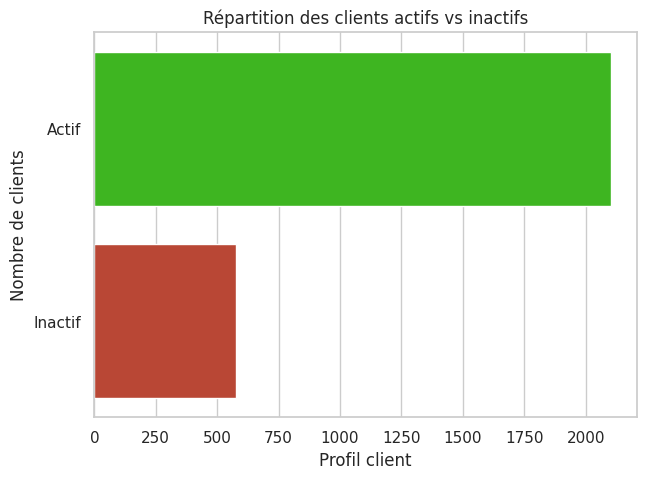

In [318]:
# Créer d'abord une dataFrame qui regoupe les tables orders et customers
analysis = orders.merge(
    customers[['customer_id', 'city', 'phone','loyalty_score']],
    on="customer_id",
    how="left"
)
# Profils des clients 
customers_activity = (
    analysis.groupby('customer_id')["order_id"]
    .count()
    .rename("Nombre_commande")
    .reset_index()
    )


customers_activity["profile"] = np.where(
    customers_activity['Nombre_commande'] >= 3,
    "Actif",
    "Inactif"
)

# Comptage 
counts = customers_activity['profile'].value_counts().rename_axis('profile').reset_index(name='count')
counts['pct'] = (counts['count'] / counts['count'].sum()) * 100

#Couleur
palette = {"Actif": "#2FCE08", "Inactif": "#cf371f"}

plt.figure(figsize=(7, 5))
# sns.countplot(data=customers_activity, x="profile")
sns.barplot(data=counts, y='profile', x='count', palette=palette, order=['Actif','Inactif'])
plt.title("Répartition des clients actifs vs inactifs")
plt.xlabel("Profil client")
plt.ylabel("Nombre de clients")
plt.show()

#### Interpretation

Ce graphique nous presentement simplement le nombre client actif et inactifs que nous avons dans notre BD. Avoir une majorité de client actif signifirait une fidélisation des clients sur les services de nexaCommerce.  

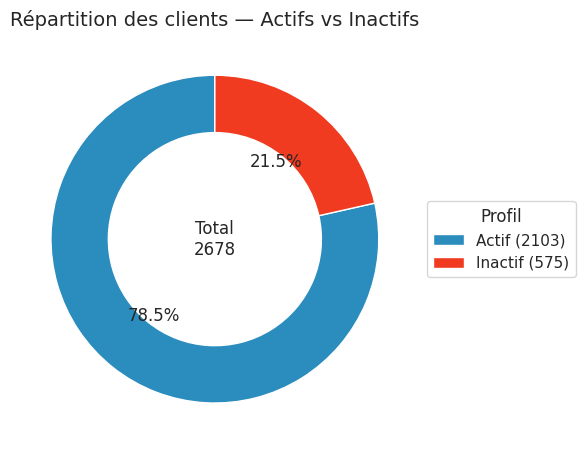

In [321]:
counts = customers_activity['profile'].value_counts().reindex(['Actif', 'Inactif']).fillna(0)
labels = counts.index.tolist()
sizes = counts.values
colors = ["#2b8cbe", "#f03b20"]  # palette personnalisée

fig, ax = plt.subplots(figsize=(6,6))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops=dict(width=0.35, edgecolor='w')
)

# Centre (donut) et légende
ax.set(aspect="equal")
plt.legend(wedges, [f"{lab} ({int(cnt)})" for lab, cnt in zip(labels, sizes)],
           title="Profil", loc="center left", bbox_to_anchor=(1, 0.5))

plt.title("Répartition des clients — Actifs vs Inactifs", fontsize=14)

# Texte central : total
total = sizes.sum()
ax.text(0, 0, f"Total\n{int(total)}", ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()

In [194]:
# ── Masque simple ────────────────────────────────────────────
mask_douala = orders['city'].str.strip().str.lower() == 'douala'
commandes_douala = orders[mask_douala]
print(f'Commandes Douala : {len(commandes_douala):,}')
# ── Masques combinés ─────────────────────────────────────────
# Commandes livrées avec montant > 10 000 FCFA
mask_livré = orders['status'].str.lower().str.strip().str.startswith('livr')
mask_montant = orders['total_amount_xaf'] > 10000
gros_livres = orders[mask_livré & mask_montant]
print(f'Gros livraisons : {len(gros_livres):,}')
# Commandes en retard OU annulées
mask_retard = orders['status'].str.lower().str.contains('retard', na=False)
mask_annulé = orders['status'].str.lower().str.contains('annul', na=False)
pb_commandes = orders[mask_retard | mask_annulé]
print(f'Retards/Annulés : {len(pb_commandes):,}')
# ── query() — Syntaxe SQL-like ────────────────────────────────
# Plus lisible pour les filtres complexes
résultat = orders.query('total_amount_xaf > 20000 and delivery_time_min < 30')
print(f'Premium rapide : {len(résultat)}')
# Avec variables locales (préfixe @)
seuil = 15000
résultat2 = orders.query('total_amount_xaf > @seuil and order_hour >= 20')
print(f'Soir/gros montant: {len(résultat2)}')
# ── isin() — Appartenance à une liste ────────────────────────
villes_cibles = ['Douala', 'douala', 'DOUALA', 'Yaoundé', 'Yaounde']
mask_villes = orders['city'].isin(villes_cibles)
print(f'Douala+Yaoundé : {mask_villes.sum():,}')
# ── between() — Plage numérique ─────────────────────────────
matin = orders[orders['order_hour'].between(6, 11)]
print(f'Commandes matin : {len(matin):,}')


Commandes Douala : 6,422
Gros livraisons : 4,997
Retards/Annulés : 3,972
Premium rapide : 804
Soir/gros montant: 867
Douala+Yaoundé : 10,557
Commandes matin : 3,513


### Boxplot livraison par ville

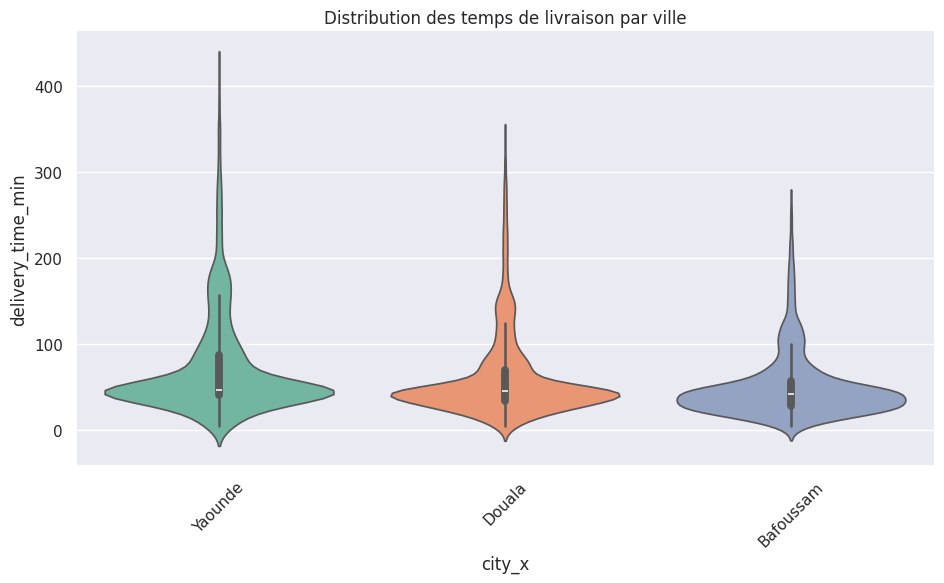

In [341]:
# Préparations
analysis_city = analysis.dropna(subset=['city_x', 'delivery_time_min'])
top_cities = analysis_city['city_x'].value_counts().nlargest(8).index
plot_df = analysis_city[analysis_city['city_x'].isin(top_cities)]

# Plot
sns.set_theme(style="darkgrid")
g = sns.catplot(
    data=plot_df,
    x="city_x", y="delivery_time_min", hue="city_x",
    kind="violin", height=6, aspect=1.6, palette="Set2", split=False
)
g.set_xticklabels(rotation=45)
plt.title("Distribution des temps de livraison par ville")
plt.tight_layout()
plt.show()


### Interpretation
Le boxplot est utile pour la visualisation du temps de livraison par ville. Avec ce boxplot on repere les villes où la performance est la plus instable. 

### Volume de commande par ville

/tmp/ipykernel_5240/1227520416.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(analysis_city, x='city_x', order=order, palette='Set1')


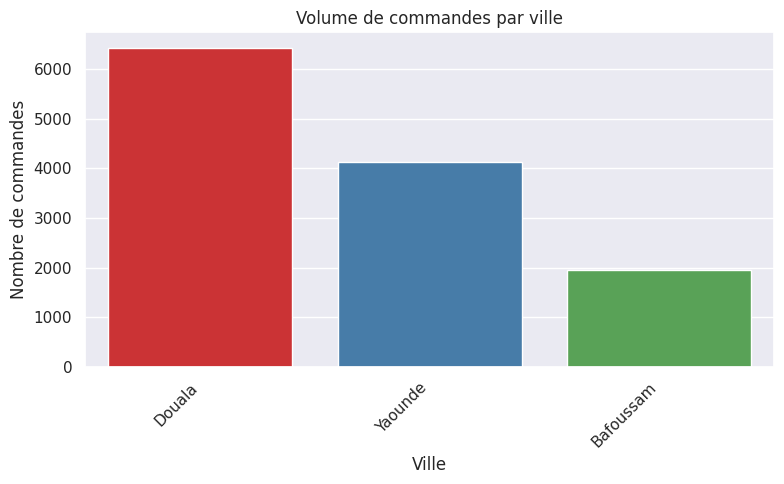

In [351]:
plt.figure(figsize=(8,5))

order = analysis_city['city_x'].value_counts().index
sns.countplot(analysis_city, x='city_x', order=order, palette='Set1')

plt.title("Volume de commandes par ville")
plt.xlabel("Ville")
plt.ylabel("Nombre de commandes")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Interpretation

Cette figure nous montre le pods des commandes dans chaque ville. C'est à dire l'activité globale dans chaque, ainsi nous pouvons identifier les zones prioritaires.  

### Livreurs les plus performants

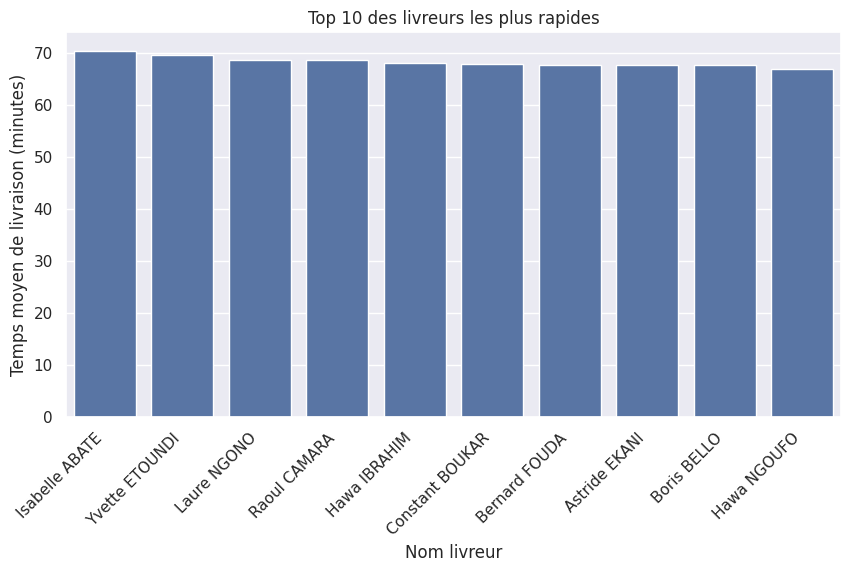

In [366]:
courier_orders = orders.merge(
    couriers,
    on="courier_id",
    how="left",
    suffixes=("_order", "_courier")
)

courier_orders.head()

fastest_couriers = (
    courier_orders.groupby(["courier_id", "name"])["delivery_time_min"]
    .mean()
    .reset_index()
    .sort_values("delivery_time_min", ascending=False)
    .head(10)
)

fastest_couriers

plt.figure(figsize=(10, 5))
sns.barplot(
    data=fastest_couriers,
    x="name",
    y="delivery_time_min"
)
plt.title("Top 10 des livreurs les plus rapides")
plt.xlabel("Nom livreur")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Temps moyen de livraison (minutes)")
plt.show()

#### Interpretation 
Le graphique nous présente les livreurs les plus perfomants.


### Temps moyen de livraison par ville 

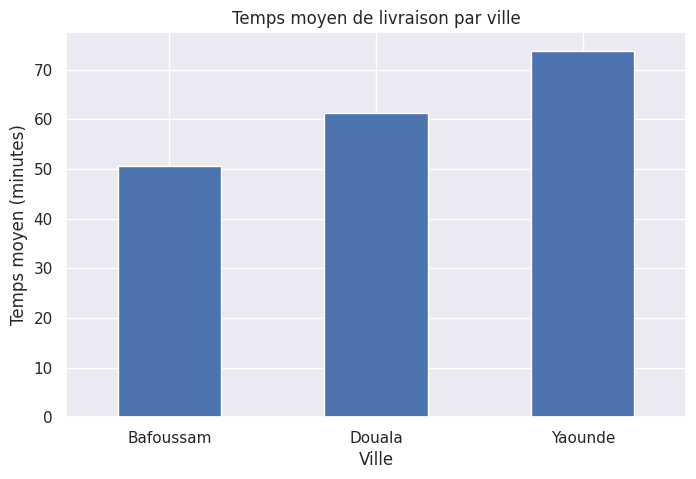

In [ ]:
city_delivery = (
    analysis.groupby("city_x")["delivery_time_min"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(8, 5))
city_delivery.plot(kind="bar")
plt.title("Temps moyen de livraison par ville")
plt.xlabel("Ville")
plt.ylabel("Temps moyen (minutes)")
plt.xticks(rotation=0)
plt.show()


#### Commentaire
Le graphique ci-contre nous montre les tempsp moyen de livraison par ville qui varie. 

### Temps moyen de livraison par jour


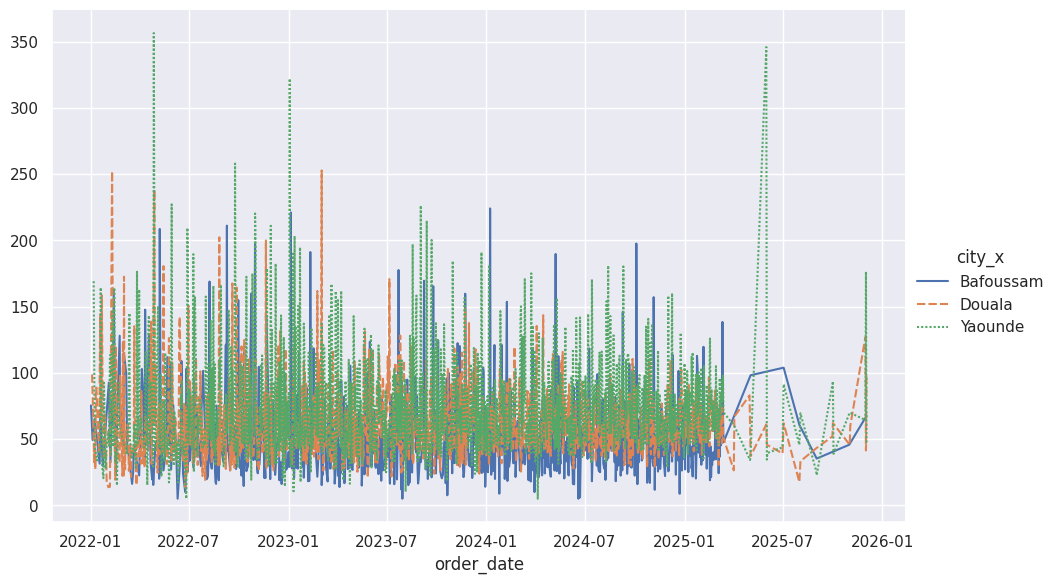

In [ ]:
daily = analysis.groupby([analysis['order_date'].dt.date, 'city_x'])['delivery_time_min'].mean().reset_index()
daily_wide = daily.pivot(index='order_date', columns='city_x', values='delivery_time_min')
sns.relplot(data=daily_wide, kind='line', height=6, aspect=1.6)

#### Interprétation
Le graphique suivant nous montre les moyennes journaliers des temps de livraison en fonction des villes. Nous constatons que la ville de yaoundé à une moyenne de temps de livraison largement supérieur au autre ville. Ceux ci peut etre du au faite que la logistique sur la ville de yaoundé pourrais etre ne pas bonne. 

### Taux de retard par ville

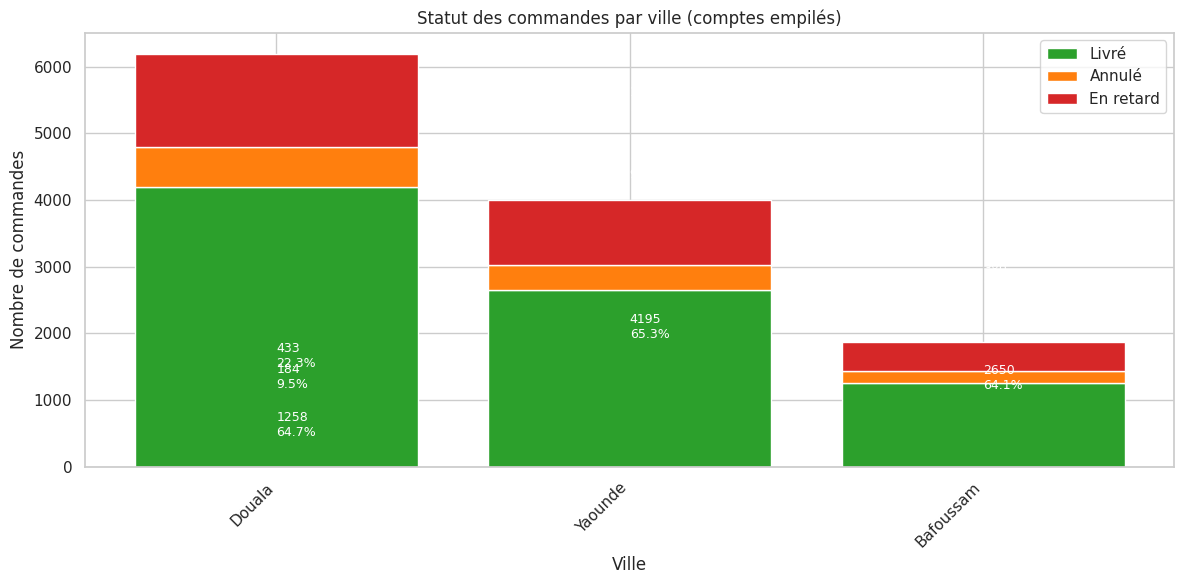

In [395]:
analysis['is_late'] = (analysis['status']== 'en_retard') 
analysis['is_delivered'] = (analysis['status']== 'livré') 
analysis['is_cancelled'] =  (analysis['status']== 'annulé')
analysis['is_running'] =  (analysis['status']== 'en_cours') 
 

# Agrégation par ville
agg = analysis.groupby('city_x')[['is_delivered', 'is_late', 'is_cancelled','is_running']].sum().reset_index()
agg['total'] = agg[['is_delivered', 'is_late', 'is_cancelled','is_running']].sum(axis=1)

# Pourcentages
for col in ['is_delivered', 'is_late', 'is_cancelled','is_running']:
    agg[col + '_pct'] = (agg[col] / agg['total']) * 100

# Trier par volume ou par taux de retard si souhaité
agg = agg.sort_values('total', ascending=False)

# Plot stacked bar raw counts
plt.figure(figsize=(12,6))
sns.set_theme(style="whitegrid")

bottom = None
colors = ["#2ca02c", "#ff7f0e", "#d62728"]  # livré, annulé, en retard (ajuster si besoin)
labels = ['Livré', 'Annulé', 'En retard']

plt.bar(agg['city_x'], agg['is_delivered'], label='Livré', color=colors[0])
plt.bar(agg['city_x'], agg['is_cancelled'], bottom=agg['is_delivered'], label='Annulé', color=colors[1])
plt.bar(agg['city_x'], agg['is_late'], bottom=agg['is_delivered']+agg['is_cancelled'], label='En retard', color=colors[2])


plt.xticks(rotation=45, ha='right')
plt.xlabel("Ville")
plt.ylabel("Nombre de commandes")
plt.title("Statut des commandes par ville (comptes empilés)")
plt.legend()

# Annoter pourcentages au-dessus des barres
for i, row in agg.iterrows():
    x = i
    y0 = 0
    for col, color, label in zip(['is_delivered', 'is_cancelled', 'is_late'], colors, labels):
        val = int(row[col])
        pct = row[col + '_pct']
        if val > 0:
            plt.text(i, y0 + val/2, f"{val}\n{pct:.1f}%", ha='left', va='center', fontsize=9, color='white')
        y0 += val

plt.tight_layout()
plt.show()

# # Option : graphes en pourcentages empilés (100%)
# plt.figure(figsize=(12,6))
# bottom_vals = np.zeros(len(agg))
# for col, color, label in zip(['is_delivered_pct', 'is_cancelled_pct', 'is_late_pct'], colors, labels):
#     plt.bar(agg['city_x'], agg[col], bottom=bottom_vals, label=label, color=color)
#     bottom_vals += agg[col].values

# plt.xticks(rotation=45, ha='right')
# plt.ylabel("Pourcentage des commandes (%)")
# plt.title("Statut des commandes par ville (100% empilé)")
# plt.legend()
# plt.tight_layout()
# plt.show()

#### Interpretation 

Le graphe nous montre les commandes livré , en retard et annulé dans les différentes villes.   

### Score des liveurs par ville

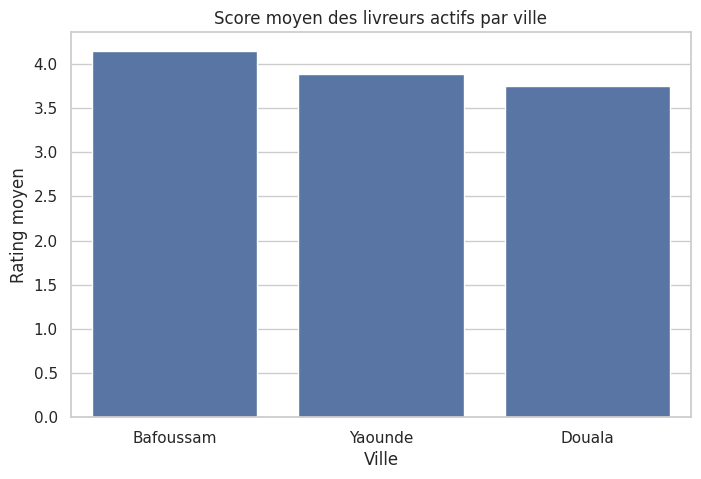

In [396]:
active_couriers = couriers[couriers["is_active"] == True].copy()
active_couriers.head()

active_couriers['city'] = active_couriers['city'].map(city_normalise)

active_courier_scores_by_city = (
    active_couriers.groupby("city")["rating"]
    .mean()
    .reset_index()
    .sort_values("rating", ascending=False)
)

active_courier_scores_by_city

plt.figure(figsize=(8, 5))
sns.barplot(
    data=active_courier_scores_by_city,
    x="city",
    y="rating"
)
plt.title("Score moyen des livreurs actifs par ville")
plt.xlabel("Ville")
plt.ylabel("Rating moyen")
plt.show()

#### Interprétation
Le graphique nous montre les villes dont les livreus actifs ont été les plus notés.  

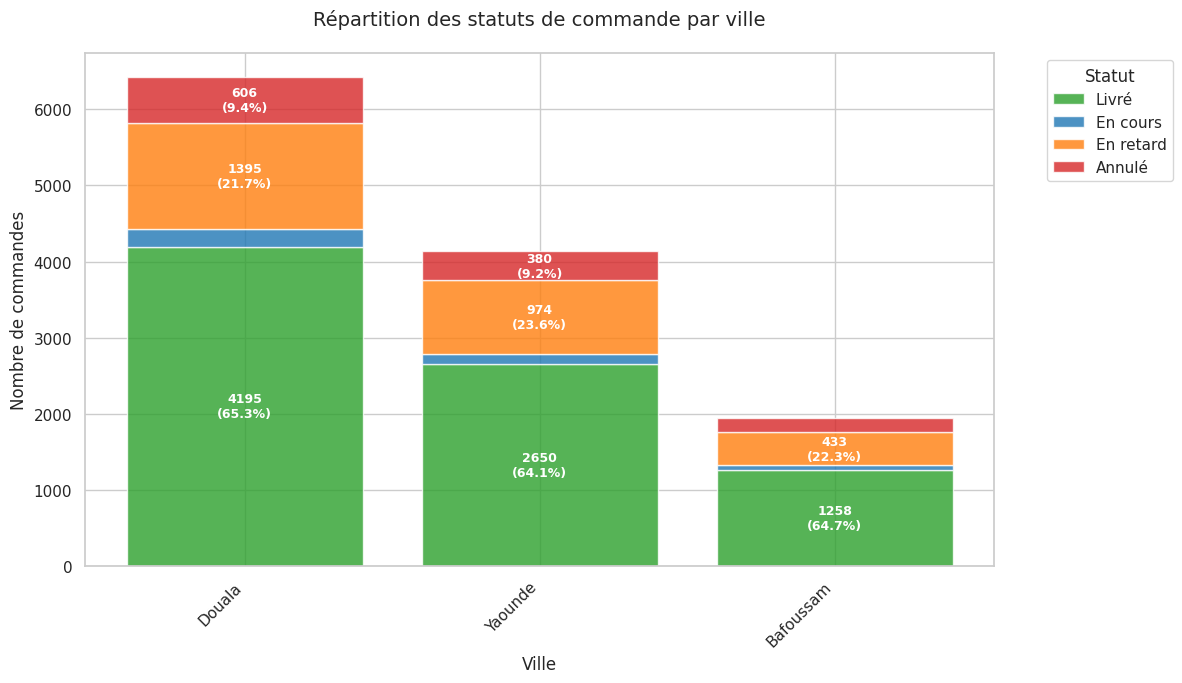

In [409]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Préparation des indicateurs
for status in ['livré', 'en_retard', 'annulé', 'en_cours']:
    col_name = f"is_{status.replace(' ', '_')}"
    analysis[col_name] = (analysis['status'] == status).astype(int)

# 2. Agrégation par ville
cols_to_sum = ['is_livré', 'is_en_retard', 'is_annulé', 'is_en_cours']
agg = analysis.groupby('city_x')[cols_to_sum].sum().reset_index()
agg['total'] = agg[cols_to_sum].sum(axis=1)

# 3. Calcul des pourcentages
for col in cols_to_sum:
    agg[col + '_pct'] = (agg[col] / agg['total']) * 100

# 4. Tri par volume total (Important pour la lisibilité)
agg = agg.sort_values('total', ascending=False).reset_index(drop=True)

# 5. Visualisation
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# Configuration des couleurs et labels (Ordre logique : Succès -> Neutre -> Echec)
plot_configs = [
    {'col': 'is_livré', 'label': 'Livré', 'color': '#2ca02c'},
    {'col': 'is_en_cours', 'label': 'En cours', 'color': '#1f77b4'},
    {'col': 'is_en_retard', 'label': 'En retard', 'color': '#ff7f0e'},
    {'col': 'is_annulé', 'label': 'Annulé', 'color': '#d62728'}
]

bottom = pd.Series([0.0] * len(agg))

for config in plot_configs:
    plt.bar(agg['city_x'], agg[config['col']], bottom=bottom, 
            label=config['label'], color=config['color'], alpha=0.8)
    
    # Ajout des annotations au milieu de chaque segment
    for idx, row in agg.iterrows():
        val = row[config['col']]
        pct = row[config['col'] + '_pct']
        if val > (agg['total'].max() * 0.05):  # On n'affiche que si le segment est assez large
            plt.text(idx, bottom[idx] + val/2, f"{int(val)}\n({pct:.1f}%)", 
                     ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    
    bottom += agg[config['col']]

plt.xticks(rotation=45, ha='right')
plt.xlabel("Ville")
plt.ylabel("Nombre de commandes")
plt.title("Répartition des statuts de commande par ville", fontsize=14, pad=20)
plt.legend(title="Statut", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


#### Interprétation
Le graphique met en évidence les commandes, taux de commandes, pourcentage de commande dans une ville. c'est à dire si Douala traite le plus gros volume, le taux de commandes 'en_retard' y est proportionnellement plus élevé qu'à Yaoundé. Ceci nous apprends que le retard sur les commandes ne sont dû au faite qu'il puisse avoir beauoup de commande dans la ville, mais plûtot au niveau de la densité de la population.

## Insight pour la direction

Ici nous identifions les idées pour aider à améliorer le service marketing et financier de nexacommerce.

1. *L'activité à certains heure de la journée.*

Est ce que le volume de commandes est complètement homogène sur le temps de la journée, mais aussi est ce que le faite de se faire livrér a certains heure de la journée pourrais avoir un impact sur le retard d'une commande. 
    Il faudrais adpater la logistique en fonction

2. *Activité sur les categories des produits*

Quelle sont les produits qui sont les plus annulés ? ex: La categorie Épicerie represente quel pourcentage dans le taux d'annulation des commandes ? L'annulation d'une commande depends t-il de son produit ? Il faudrais pouvoir elargir le réseaux pour reduire le temps d'attente pour un produit qu'on peut possiblement trouvé à côté.

3. *Fidélisation et clientelle*

Est ce que les clients les plus fidèle sont plus servis que les autres ? Est ce que les clients premium avec un fort panier moyen ont un privilège par rapport au autre client ? Est ce qu'il exite une corrélation entre le loyalty_score d'un client et son pannier moyen ? Il faudrais que les clients les plus fidèles soit les plus satisfait pour augmenter le panier moyen de celui ci et recevoir d'autre client. 

4. *Annulation de commandes*

Est ce que les annulations de commandes sont dûe au faites de ne pas avoir de la monaie ? Alors pour cela il faudrais encourager les méthodes de paiement mobiles pour éviter les annulations. 

5. *Performance des liveurs*

Les livreurs les plus performant recoivent t-il un meilleur salaire ? Avons nous beaucoup de temps de livraison qui sont en dehors des outliers ont un impacte sur la finance ?  Pour les livreurs les plus prompts il faudrais pouvoir leur fournir une récompenses.

## Exécutive Summary

Cette analyse vise à évaluer la performance opérationnelle et commerciale de NexaCommerce à partir des données de commandes, clients et livreurs, afin d’identifier les leviers d’optimisation logistique et de croissance de l'entreprise.
L'analyse de plus de 5 ans de données opérationnelles confirme une trajectoire de croissance solide pour NexaCommerce puis une chute brutale vers février 2025. 
Cependant, l'histoire des données révèle des frictions logistiques critiques à Yaoundé et lors des pics d'activité qui freinent la rentabilité et la fidélisation client du côté de yaoundé. Mais par ailleur nous avons aussi nombre de retard dans la ville de douala  qui est plus ou moins pareille que le pourcentage de retard dans la ville de Yaoundé ce qui prouve que le retard des commandes ne dépends pas de la quantité de commande mais de la logistique.
La donnée nous raconte alors : 
- Résoudre les problèmes de logistique dans la ville de yaoundé.

- Douala est le principal levier de croissance avec un fort impact.   

- La qualité de données (ex: numero télephone table customers, ainsi que les montants) est un problème dans les analyses.

- Les  retards repete est un soucis pour l'expérience client. 

Les recomandations proposez par rapport à ça serais : 

-  Prioriser la logistique à yaoundé.

-  Prioriser la logistique à certaines heure de la journée 

-  Mettre en place un suivi des client premium 